In [2]:
import pandas as pd
df = pd.read_csv('complaints.csv')

/tmp/ipykernel_11624/1484896287.py:2: DtypeWarning: Columns (0: Consumer complaint narrative) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('complaints.csv')


In [3]:
df["Date received"] = pd.to_datetime(df["Date received"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16962062 entries, 0 to 16962061
Data columns (total 16 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   Date received                 datetime64[us]
 1   Product                       str           
 2   Sub-product                   str           
 3   Issue                         str           
 4   Sub-issue                     str           
 5   Consumer complaint narrative  str           
 6   Company public response       str           
 7   Company                       str           
 8   State                         str           
 9   ZIP code                      str           
 10  Tags                          str           
 11  Submitted via                 str           
 12  Date sent to company          str           
 13  Company response to consumer  str           
 14  Timely response?              str           
 15  Complaint ID                  int64      

### Inputs and Label/Outputs
#### Input columns :
- Costumer complain narrative
#### Output columns :
- Product
- Sub-Product
- Issue
- Sub-issue

- As we can see right here the label are <strong> not independant </strong> so they are going to be predecited <strong> sequentially </strong>

## Checking NA Values per Columns

In [4]:
print("Consumer complaint narrative NA values " + str(sum(pd.isna(df["Consumer complaint narrative"])==True)))
print("Product NA values " + str(sum(pd.isna(df["Product"])==True)))
print("Sub-product narrative NA values " + str(sum(pd.isna(df["Sub-product"])==True)))
print("Issue " + str(sum(pd.isna(df["Issue"])==True)))
print("Sub-issue " + str(sum(pd.isna(df["Sub-issue"])==True)))


Consumer complaint narrative NA values 13130557
Product NA values 0
Sub-product narrative NA values 235275
Issue 6
Sub-issue 925650


#### Metadata / potentially useful later
- Company
- State
- Submitted via
- Date received

### Investigating Product

In [5]:
mask = pd.isna(df["Consumer complaint narrative"])==False 
df[mask]["Product"].value_counts()

Product
Credit reporting or other personal consumer reports                             1671615
Credit reporting, credit repair services, or other personal consumer reports     807499
Debt collection                                                                  439160
Checking or savings account                                                      185789
Mortgage                                                                         145889
Credit card                                                                      125987
Money transfer, virtual currency, or money service                               120206
Credit card or prepaid card                                                      108683
Student loan                                                                      62409
Vehicle loan or lease                                                             52739
Credit reporting                                                                  31587
Payday loan, title loan,

In [6]:
mask1 = pd.isna(df["Consumer complaint narrative"])==False
mask3 = df["Product"] == "Credit reporting or other personal consumer reports"
mask4 = df["Product"] == "Credit reporting, credit repair services, or other personal consumer reports"
df1 = df[mask1][mask3]["Date received"].sort_values()
df2 = df[mask1][mask4]["Date received"].sort_values()
print("' Earliest Date Credit reporting, credit repair services, or other personal consumer reports'" + str(df2.iloc[0]))
print("' Latest Date Credit reporting, credit repair services, or other personal consumer reports'" + str(df2.iloc[len(df2)-1]))
print("' Earliest Date Credit reporting or other personal consumer reports'" + str(df1.iloc[0]))
print("' Latest Date Credit reporting or other personal consumer reports'" + str(df1.iloc[len(df1)-1]))

/tmp/ipykernel_11624/510115542.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df[mask1][mask3]["Date received"].sort_values()
/tmp/ipykernel_11624/510115542.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df[mask1][mask4]["Date received"].sort_values()


' Earliest Date Credit reporting, credit repair services, or other personal consumer reports'2017-04-24 00:00:00
' Latest Date Credit reporting, credit repair services, or other personal consumer reports'2023-08-25 00:00:00
' Earliest Date Credit reporting or other personal consumer reports'2023-08-25 00:00:00
' Latest Date Credit reporting or other personal consumer reports'2026-07-27 00:00:00


#### Results Shows clean boundary
<p> - Date Credit reporting, credit repair services, or other personal consumer reports : 2017-04-24 -> 2023-08-25 </p>
<p> - Date Credit reporting or other personal consumer reports: 2023-08-25 -> 2026-07-27 </p>

So this is only a Taxonomy label changed . 
Our main problem now if we won't lose all the data .. so mapping the old label to the new label would probably make certain noise

In [7]:
print(df[mask1][mask3]["Sub-product"].unique())
print(df[mask1][mask4]["Sub-product"].unique())

/tmp/ipykernel_11624/929768596.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df[mask1][mask3]["Sub-product"].unique())


<StringArray>
['Credit reporting', 'Other personal consumer report']
Length: 2, dtype: str


/tmp/ipykernel_11624/929768596.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df[mask1][mask4]["Sub-product"].unique())


<StringArray>
[              'Credit reporting', 'Other personal consumer report',
         'Credit repair services',     'Conventional home mortgage']
Length: 4, dtype: str


In [8]:
mask5 = (pd.isna(df["Consumer complaint narrative"])==False) & (df["Product"] == "Credit reporting, credit repair services, or other personal consumer reports") & (df["Sub-product"] == "Credit repair services")
#print(df[mask5])
df_sorted = df[mask5].sort_values(by=['Date received'])
print(df_sorted.iloc[0])
print(df_sorted.iloc[len(df_sorted)-1])

Date received                                                 2017-04-29 00:00:00
Product                         Credit reporting, credit repair services, or o...
Sub-product                                                Credit repair services
Issue                                                               Fraud or scam
Sub-issue                                                                     NaN
Consumer complaint narrative    This company AD Astra Recovery .The amount sho...
Company public response                                                       NaN
Company                                            Ad Astra Recovery Services Inc
State                                                                          TX
ZIP code                                                                    752XX
Tags                                                                          NaN
Submitted via                                                                 Web
Date sent to com

### As mentioned in Taxonomy document
moved “Credit repair services” under the new added product, “Debt or credit management”

In [9]:
mask6 = (pd.isna(df["Consumer complaint narrative"])==False) & (df["Product"] == "Debt or credit management") & (df["Sub-product"] == "Credit repair services")
df_sorted = df[mask6].sort_values(by=['Date received'])
print(df_sorted.iloc[0])


Date received                                                 2023-08-25 00:00:00
Product                                                 Debt or credit management
Sub-product                                                Credit repair services
Issue                                               Problem with customer service
Sub-issue                                                                     NaN
Consumer complaint narrative    XX/XX/23 I logged into my Transunion paid subs...
Company public response         Company has responded to the consumer and the ...
Company                                    TRANSUNION INTERMEDIATE HOLDINGS, INC.
State                                                                          AZ
ZIP code                                                                    853XX
Tags                                                                          NaN
Submitted via                                                                 Web
Date sent to com

In [10]:
print(df[mask5]["Issue"].unique())
print('_____________')
print(df[mask6]["Issue"].unique())

<StringArray>
[                'Confusing or missing disclosures',
                                    'Fraud or scam',
                                   'Excessive fees',
                    'Problem with customer service',
 'Confusing or misleading advertising or marketing',
                         'Unexpected or other fees']
Length: 6, dtype: str
_____________
<StringArray>
[                'Confusing or missing disclosures',
                 'Didn't provide services promised',
 'Confusing or misleading advertising or marketing',
               'Charged upfront or unexpected fees',
                    'Problem with customer service']
Length: 5, dtype: str


As from the documents :
- The issue “Excessive fees” was removed under the sub-product “Credit repair services”. (removed)
- revised “Fraud or scam” issue to “Didn’t provide services promised” under “Credit
repair services”
- "Unexpected or other fees" revised to Charged upfront or unexpected fees

The problem here is that <strong>Excessive fees</strong> was removed .. so what should we do ?

In [11]:
mask = mask5 & (df["Issue"] == "Excessive fees")
df[mask].info()

<class 'pandas.DataFrame'>
Index: 147 entries, 2986343 to 16921290
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date received                 147 non-null    datetime64[us]
 1   Product                       147 non-null    str           
 2   Sub-product                   147 non-null    str           
 3   Issue                         147 non-null    str           
 4   Sub-issue                     0 non-null      str           
 5   Consumer complaint narrative  147 non-null    str           
 6   Company public response       42 non-null     str           
 7   Company                       147 non-null    str           
 8   State                         147 non-null    str           
 9   ZIP code                      147 non-null    str           
 10  Tags                          38 non-null     str           
 11  Submitted via                 147 non

<strong> As number of rows here is 147 , we would exclude them from the training process </strong>

In [12]:
mask = mask5 & (df["Issue"] == "Fraud or scam")
df[mask].info()

<class 'pandas.DataFrame'>
Index: 998 entries, 2985577 to 16949141
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date received                 998 non-null    datetime64[us]
 1   Product                       998 non-null    str           
 2   Sub-product                   998 non-null    str           
 3   Issue                         998 non-null    str           
 4   Sub-issue                     0 non-null      str           
 5   Consumer complaint narrative  998 non-null    str           
 6   Company public response       365 non-null    str           
 7   Company                       998 non-null    str           
 8   State                         988 non-null    str           
 9   ZIP code                      998 non-null    str           
 10  Tags                          184 non-null    str           
 11  Submitted via                 998 non

In [14]:
mask = mask5 & (df["Issue"] == "Unexpected or other fees")
df[mask].info()

<class 'pandas.DataFrame'>
Index: 342 entries, 2993879 to 16933797
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date received                 342 non-null    datetime64[us]
 1   Product                       342 non-null    str           
 2   Sub-product                   342 non-null    str           
 3   Issue                         342 non-null    str           
 4   Sub-issue                     0 non-null      str           
 5   Consumer complaint narrative  342 non-null    str           
 6   Company public response       181 non-null    str           
 7   Company                       342 non-null    str           
 8   State                         341 non-null    str           
 9   ZIP code                      342 non-null    str           
 10  Tags                          56 non-null     str           
 11  Submitted via                 342 non

As we finished checking what happens with Credit repair services now let's check 'Conventional home mortgage'

In [18]:
mask_sub_product = (pd.isna(df["Consumer complaint narrative"])==False) & (df["Product"] == "Credit reporting, credit repair services, or other personal consumer reports") & (df["Sub-product"] == "Conventional home mortgage")
df[mask_sub_product].info()

<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 14581735 to 14581735
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date received                 1 non-null      datetime64[us]
 1   Product                       1 non-null      str           
 2   Sub-product                   1 non-null      str           
 3   Issue                         1 non-null      str           
 4   Sub-issue                     0 non-null      str           
 5   Consumer complaint narrative  1 non-null      str           
 6   Company public response       0 non-null      str           
 7   Company                       1 non-null      str           
 8   State                         1 non-null      str           
 9   ZIP code                      1 non-null      str           
 10  Tags                          0 non-null      str           
 11  Submitted via                 1 n

In [47]:
mask_product = (pd.isna(df["Consumer complaint narrative"])==False)
result = (
    df[mask_product]
    .groupby(['Product','Sub-product','Issue','Sub-issue'],dropna=False) # no Nan dropped as groupby does that normally
    .size()
)
print(result)

Product                  Sub-product                   Issue                                     Sub-issue
Bank account or service  (CD) Certificate of deposit   Account opening, closing, or management   NaN          182
                                                       Deposits and withdrawals                  NaN           76
                                                       Making/receiving payments, sending money  NaN            9
                                                       Problems caused by my funds being low     NaN            2
                                                       Using a debit or ATM card                 NaN            5
                                                                                                             ... 
Virtual currency         Domestic (US) money transfer  Fraud or scam                             NaN            4
                                                       Money was not available when promised   

In [59]:
result_sorted = result.sort_values(ascending=False)

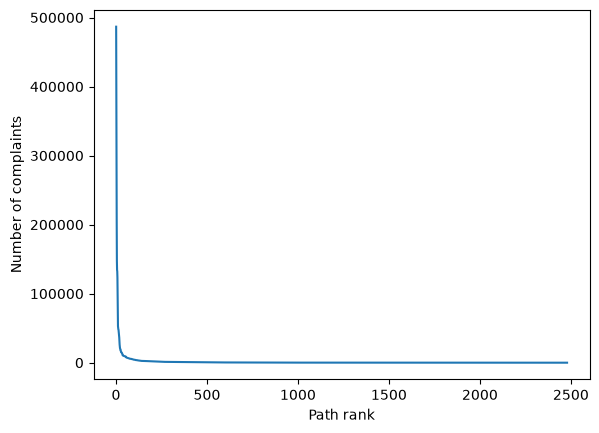

In [60]:
import matplotlib.pyplot as plt
import numpy as np
x = range(1, len(result) + 1)
y = result_sorted.to_numpy()

plt.plot(x, y)

plt.xlabel("Path rank")
plt.ylabel("Number of complaints")
plt.show()